### Data Preprocessing


In [94]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
df = pd.read_excel("healthcare_realistic_dataset_515_rows.xlsx")
df.head()

,Patient_ID,Age,Gender,Blood_Group,Height_cm,Weight_kg,BMI,Disease,Department,City,Admission_Date,Discharge_Date,Treatment_Cost,Insurance_Status,Outcome
0,P0001,24.0,Male,A+,162,56.0,21.3,Migraine,Pulmonology,Kolkata,2025-07-28,2025-08-06,92083.0,No,Recovered
1,P0002,38.0,Male,B+,153,88.0,37.6,Diabetes,General Medicine,Hyderabad,2025-10-15,2025-10-26,27967.0,No,Recovered
2,P0003,18.0,Male,B+,165,102.0,37.5,Asthma,Cardiology,Delhi,2025-02-22,2025-02-24,243852.0,No,Critical
3,P0004,79.0,Female,O-,161,105.0,40.5,COVID-19,Pulmonology,Patna,2025-01-19,2025-01-29,143169.0,No,Recovered
4,P0005,68.0,Female,O+,186,110.0,31.8,Arthritis,Pulmonology,Pune,2025-08-11,2025-08-29,227125.0,Yes,Critical


In [96]:
df.shape

(515, 15)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        515 non-null    object 
 1   Age               489 non-null    float64
 2   Gender            489 non-null    object 
 3   Blood_Group       489 non-null    object 
 4   Height_cm         515 non-null    int64  
 5   Weight_kg         490 non-null    float64
 6   BMI               515 non-null    float64
 7   Disease           489 non-null    object 
 8   Department        515 non-null    object 
 9   City              515 non-null    object 
 10  Admission_Date    515 non-null    object 
 11  Discharge_Date    515 non-null    object 
 12  Treatment_Cost    488 non-null    float64
 13  Insurance_Status  515 non-null    object 
 14  Outcome           515 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 60.5+ KB


In [98]:
df.isnull().sum()

Patient_ID           0
Age                 26
Gender              26
Blood_Group         26
Height_cm            0
Weight_kg           25
BMI                  0
Disease             26
Department           0
City                 0
Admission_Date       0
Discharge_Date       0
Treatment_Cost      27
Insurance_Status     0
Outcome              0
dtype: int64

In [99]:
del df["Height_cm"]
del df["Weight_kg"]

In [100]:
df.drop_duplicates(inplace=True)

In [101]:
df.shape

(500, 13)

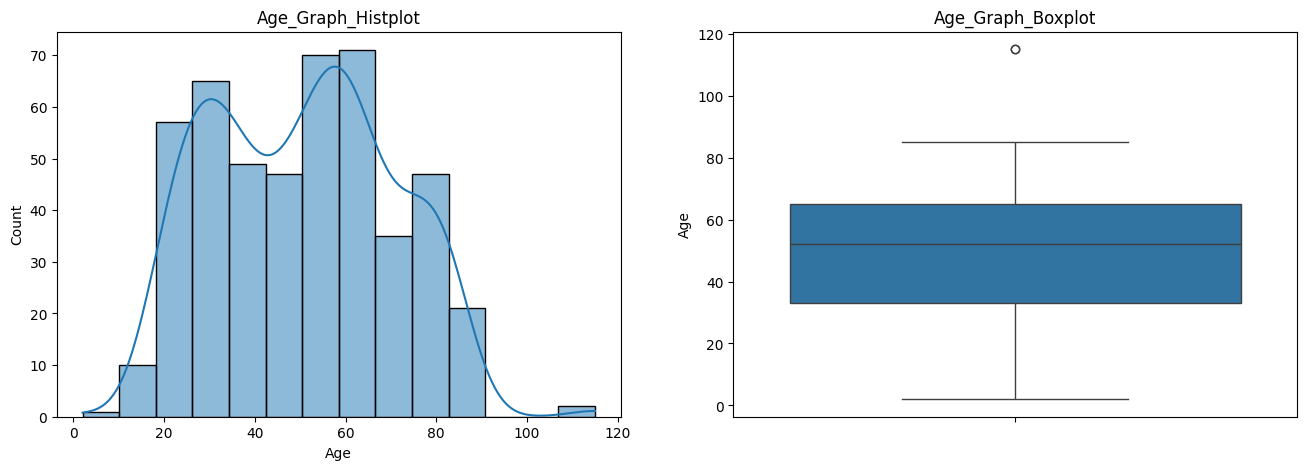

In [102]:
plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
sns.histplot(df["Age"], kde=True)
plt.title("Age_Graph_Histplot")

plt.subplot(1, 2, 2)
sns.boxplot(df["Age"])
plt.title("Age_Graph_Boxplot")
plt.show()

In [103]:
# Above graph shows outliers, therefore we use median
df["Age"].fillna(df["Age"].median(),inplace=True)

C:\Users\waghv\AppData\Local\Temp\ipykernel_87884\4131061754.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [104]:
# fill values 

df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)
df["Blood_Group"].fillna(df["Blood_Group"].mode()[0],inplace=True)
df["Disease"].fillna("Unknown",inplace=True)

C:\Users\waghv\AppData\Local\Temp\ipykernel_87884\2791219087.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)
C:\Users\waghv\AppData\Local\Temp\ipykernel_87884\2791219087.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


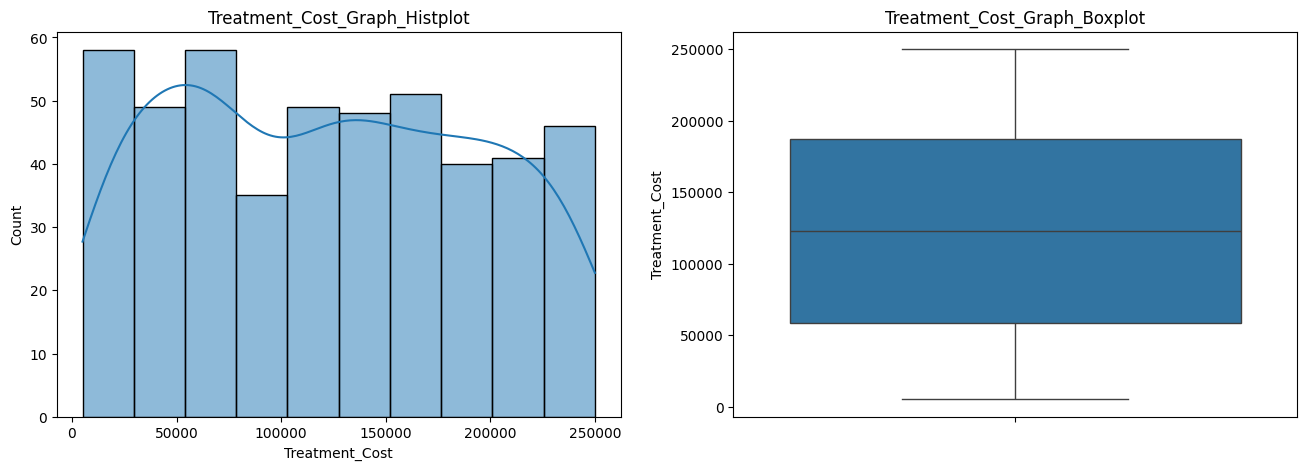

In [105]:
plt.figure(figsize=(16,5))
plt.subplot(1, 2, 1)
sns.histplot(df["Treatment_Cost"], kde=True)
plt.title("Treatment_Cost_Graph_Histplot")

plt.subplot(1, 2, 2)
sns.boxplot(df["Treatment_Cost"])
plt.title("Treatment_Cost_Graph_Boxplot")
plt.show()

In [106]:
#  According to above graph,there is not outliers then we can used mean() to fill Treatment_Cost
df["Treatment_Cost"].fillna(df["Treatment_Cost"].mean(),inplace=True)

C:\Users\waghv\AppData\Local\Temp\ipykernel_87884\1321533904.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Treatment_Cost"].fillna(df["Treatment_Cost"].mean(),inplace=True)


In [107]:
df.isnull().sum()

Patient_ID          0
Age                 0
Gender              0
Blood_Group         0
BMI                 0
Disease             0
Department          0
City                0
Admission_Date      0
Discharge_Date      0
Treatment_Cost      0
Insurance_Status    0
Outcome             0
dtype: int64

In [108]:
# Change Data Type of "Admission_Date" and "Discharge_Date" 

df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Patient_ID        500 non-null    object        
 1   Age               500 non-null    float64       
 2   Gender            500 non-null    object        
 3   Blood_Group       500 non-null    object        
 4   BMI               500 non-null    float64       
 5   Disease           500 non-null    object        
 6   Department        500 non-null    object        
 7   City              500 non-null    object        
 8   Admission_Date    500 non-null    datetime64[ns]
 9   Discharge_Date    500 non-null    datetime64[ns]
 10  Treatment_Cost    500 non-null    float64       
 11  Insurance_Status  500 non-null    object        
 12  Outcome           500 non-null    object        
dtypes: datetime64[ns](2), float64(3), object(8)
memory usage: 54.7+ KB


In [110]:
df.to_csv("cleaned_healthcare_realistic_dataset.csv", index=False)